<a href="https://colab.research.google.com/github/kerichhezron-source/Machine-Learning-Projects-/blob/main/Hezron's_DARK_NET_Light_in_the_Dark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_csv("/content/Agora.csv.zip", encoding="latin1")
df.columns = [x.replace(" ", "") for x in df.columns]
print("Data Load Complete")

df.Item = df.Item.astype(str)

for x in ["Origin","Destination"]:
    df[x] = df[x].str.capitalize().str.replace('[^\w\s]', '', regex=True)
    df[x] = df[x].str.replace(r"\bonly\b", '', regex=True).str.strip()
    # Fixed: Single (?i) at the very start of the expression
    df.loc[df[x].str.contains(r"(?i)world|\bword\b|global", na=False, regex=True), x] = "Worldwide"
    df.loc[df[x].str.contains(r"(?i)kingdom", na=False, regex=True), x] = "Uk"
    df.loc[df[x].str.contains(r"(?i)(\bunited states\b)|\bus\b", na=False, regex=True), x] = "Usa"
print("Cleaning of 'Origin' and 'Destination' Complete")

df["BTC"] = df['Price'].str.replace('BTC', '', regex=False)
df = df[pd.notnull(df['BTC'])]

regex1= r'[a-zA-Z]{2}|[/]'
df = df[~df['BTC'].str.contains(regex1, regex=True)]
df.BTC = pd.to_numeric(df.BTC)

df["Value"] = (df.BTC * 399).round(3)
df["LogValue"]= np.log(df.Value).round(3)
print("Bitcoin/Value Variable Cleaned")

df["Score"]= df.Rating.str.split('/').str[0]
df["Deals"] = "NaN"
df.loc[df.Score.str.contains(r"(deal)", na=False, regex=True), "Deals"] = df.Score
df.loc[df.Score.str.contains(r"(deal)", na=False, regex=True), "Score"] = "NaN"
df.Score = df.Score.str.replace(r'(~)', '', regex=True)
df.Score = pd.to_numeric(df.Score, errors='coerce')
df.Deals = df.Deals.str.extract('(\d+)')
print("Rating and Deal Variable Cleaned and Expanded")

df = pd.concat([df,df.Category.str.split('/', expand=True)], axis=1)
df = df.rename(columns={0: 'cat1', 1: 'cat2',2: 'cat3', 3: 'cat4'})
print("Item Category Variable Cleaned and Expanded")

df = df[df.BTC<4000]
df.loc[df.BTC > 1000, "Value"] = df.BTC
print("Bitcoin and Dollar Value Unit Mix-Up partially delt with..")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Agora.csv.zip'

### Data Loading and Initial Cleaning
In this block, we:
1.  **Import Libraries**: Set up pandas, numpy, and visualization tools.
2.  **Load Data**: Read the Agora dataset and clean column names by removing spaces.
3.  **Clean Locations**: Standardize 'Origin' and 'Destination' using regex to group variations like 'US' and 'United States' into 'Usa'.
4.  **Price Conversion**: Extract numeric BTC values, calculate a 'Value' in USD (using a fixed multiplier), and create a log-scale variable for better visualization.
5.  **Rating Expansion**: Split the 'Rating' column to extract numerical scores and deal counts.
6.  **Category Splitting**: Break the hierarchical 'Category' string into four distinct levels (`cat1` through `cat4`).

In [ ]:
def custom_describe(df):
    """
    I am a non-comformist :)
    """
    unique_count = []
    for x in df.columns:
        mode = df[x].mode().iloc[0]
        unique_count.append([x,
                             len(df[x].unique()),
                             df[x].isnull().sum(),
                             mode,
                             df[x][df[x]==mode].count(),
                             df[x].dtypes])
    print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
    return pd.DataFrame(unique_count, columns=["Column","Unique","Missing","Mode","Mode Occurence","dtype"]).set_index("Column").T

custom_describe(df)

NameError: name 'df' is not defined

### Custom Data Description
This function provides a comprehensive summary of the DataFrame, showing unique counts, missing values, the most frequent value (mode), and its occurrence for every column. It helps identify data sparsity and dominant categories.

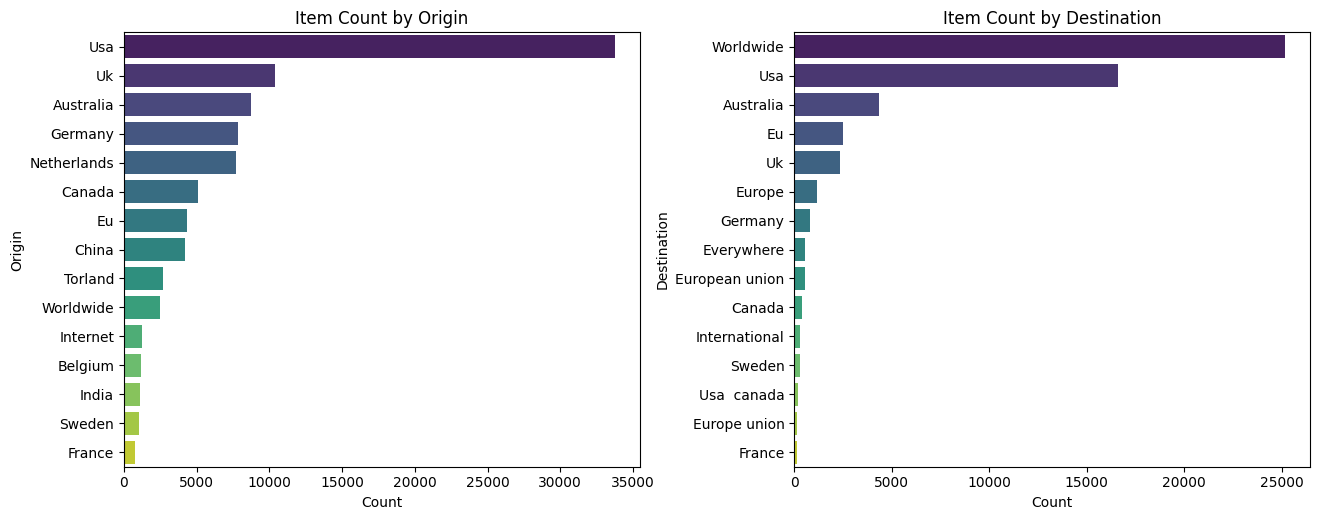

In [ ]:
f, (ax1, ax2) = plt.subplots(1,2,figsize=(13,5))
target = "Origin"
bar_count1 = df.groupby([target])[['LogValue']].count().reset_index().sort_values(by='LogValue',ascending=False)[:15]
ax1 = sns.barplot(x="LogValue", y=target, data=bar_count1, ax=ax1,palette="viridis")
ax1.set_xlabel('Count')
ax1.set_title('Item Count by {}'.format(target))
ax1.set_ylabel('{}'.format(target))

target = "Destination"
bar_count2 = df.groupby([target])[['LogValue']].count().reset_index().sort_values(by='LogValue',ascending=False)[:15]
ax2 = sns.barplot(x="LogValue", y=target, data=bar_count2,ax=ax2,palette="viridis")
ax2.set_xlabel('Count')
ax2.set_title('Item Count by {}'.format(target))
ax2.set_ylabel('{}'.format(target))
plt.tight_layout(pad=0)
plt.show()

### Item Count by Origin and Destination
These bar plots visualize the top 15 sources and destinations for listings. It clearly shows the dominance of the USA as an origin and 'Worldwide' as the most common destination.

In [ ]:
df.loc[df.Destination.str.contains(r"(?i)united|you|captivity", na=False, regex=True), "Destination"].unique()[:10]

array(['Youtube', 'Of captivity to americana',
       'Of captivity to mamas house and papas house', 'Your pm',
       'You  free shipping',
       'Of captivity to gentle hearts and kind people', 'Your inbox',
       'Of captivity to my ninjas', 'You',
       'Of captivity to left and right coast usa'], dtype=object)

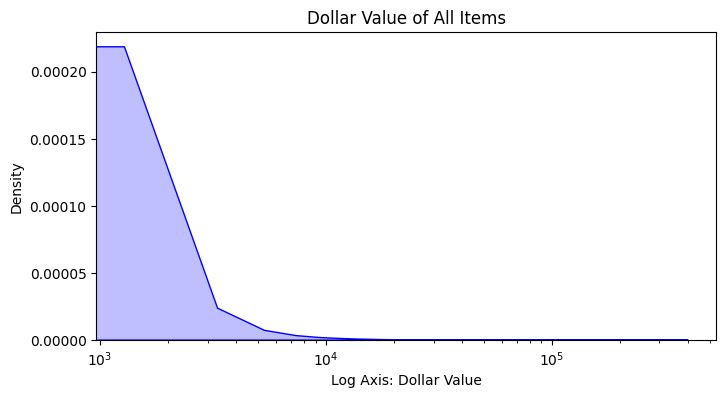

In [ ]:
plt.subplots(figsize=(8,4))
ax = sns.kdeplot(df.Value, shade=True, color="b")
ax.set_xlabel('Log Axis: Dollar Value')
ax.set_title('Dollar Value of All Items')
ax.set_ylim(0,)
ax.set(xscale="log")
plt.show()

### Distribution of Item Values
Using a Kernel Density Estimate (KDE) plot with a log-scale x-axis, we visualize the distribution of listing prices. This reveals the typical price range of items on the market while accounting for extreme outliers.

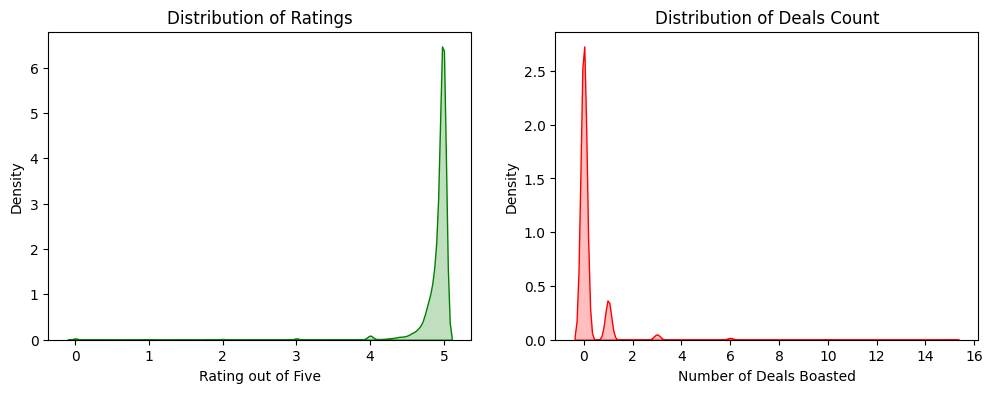

In [ ]:
f, ax = plt.subplots(1,2,figsize=(12,4))
sns.kdeplot(df.Score, shade=True, color="g", ax=ax[0])
ax[0].set_xlabel('Rating out of Five')
ax[0].set_title('Distribution of Ratings')

# Convert Deals to numeric to allow KDE plotting
df.Deals = pd.to_numeric(df.Deals, errors='coerce')

sns.kdeplot(df.Deals, shade=True, color="r", ax=ax[1])
ax[1].set_xlabel('Number of Deals Boasted')
ax[1].set_title('Distribution of Deals Count')
plt.show()

### Ratings and Deals Distribution
These plots show:
*   **Ratings**: Most vendors have very high ratings (near 5.0).
*   **Deals**: The distribution of the number of deals successful vendors have completed.

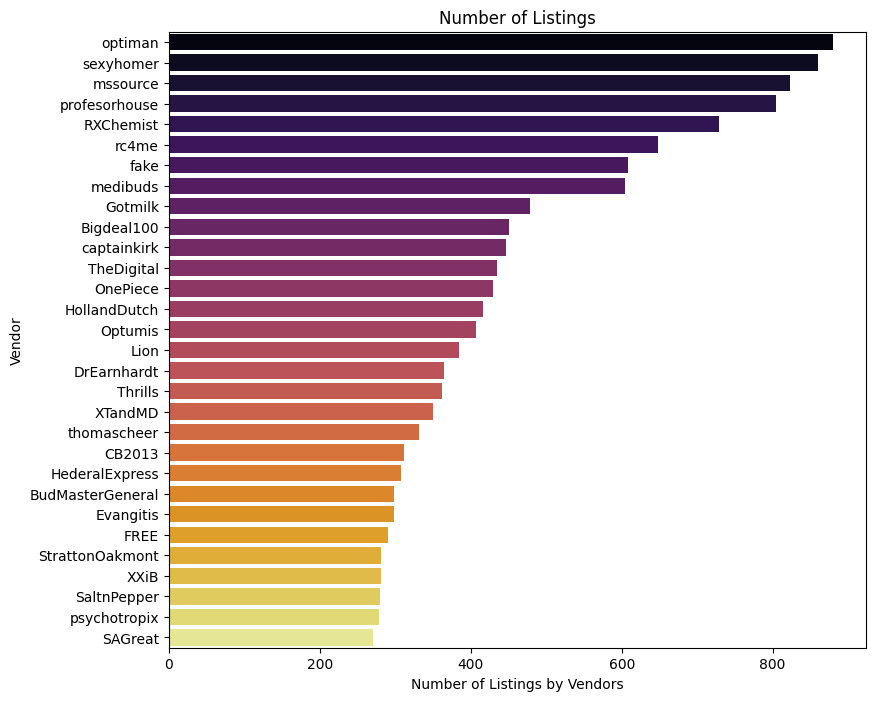

In [ ]:
n=30
f, ax = plt.subplots(figsize=[9,8])
sns.countplot(y=df.loc[df.Vendor.isin(df["Vendor"].value_counts().index[:n]),"Vendor"],order=df["Vendor"].value_counts().index[:n],palette="inferno",ax=ax)
ax.set_xlabel('Number of Listings by Vendors')
ax.set_title('Number of Listings')
plt.show()

### Top Vendor Activity
This horizontal count plot identifies the top 30 most active vendors based on the total number of listings they have posted.

In [ ]:
print("Glance into the Group and Subgroup Structure:")
df.loc[:,["Category","cat1","cat2","cat3","cat4"]].sample(7)

Glance into the Group and Subgroup Structure:


,Category,cat1,cat2,cat3,cat4
5660,Drugs/Cannabis/Weed,Drugs,Cannabis,Weed,None
98105,Drugs/Cannabis/Hash,Drugs,Cannabis,Hash,None
104006,Drugs/Steroids,Drugs,Steroids,None,None
78736,Drugs/Dissociatives/MXE,Drugs,Dissociatives,MXE,None
22427,Drugs/Stimulants/Speed,Drugs,Stimulants,Speed,None
40712,Data/Accounts,Data,Accounts,None,None
77573,Drugs/Cannabis/Weed,Drugs,Cannabis,Weed,None


In [ ]:
def catplot(target, level):
    f, (ax1, ax2) = plt.subplots(1,2,figsize=(15,8), sharey=True)
    bar_count1 = df.groupby([target])[['LogValue']].count().sort_values(by='LogValue',ascending=False)
    ax1 = sns.barplot(x="LogValue", y=bar_count1.index, data=bar_count1, ax=ax1)
    ax1.set_xlabel('Count')
    ax1.set_title('Item Count by {}'.format(level))
    ax1.set_ylabel('{}'.format(level))

    # Box Plot
    ax2 = sns.boxplot(y=target, x="Value",order=bar_count1.index, data=df)
    ax2.set_xlabel('Log Dollar Value')
    ax2.set_title('Log Dollar Value for {}'.format(level))
    ax2.set_ylabel('')

    # Plot
    f.suptitle("Count and Box Plot for {}".format(level),fontsize=20)
    f.tight_layout(rect=[0, 0.03, 1, 0.95])

# Simple Count Plot Helper Function
def countplot(level, label):
    plt.subplots(figsize=(8,7))
    bar_count= df.groupby([level])[['LogValue']].count().reset_index().sort_values(by='LogValue',ascending=False)
    ax = sns.barplot(x="LogValue", y=level, data=bar_count,palette="viridis")
    ax.set_xlabel('Count')
    ax.set_title('Item Count by {}'.format(label))
    ax.set_ylabel('General Categories')
    plt.show()

# Count and Box for Category Level
def catplot(target, level, size = (13,6)):
    f, (ax1, ax2) = plt.subplots(1,2,figsize=size, sharey=True)
    bar_count1 = df.groupby([target])[['Value']].count().sort_values(by='Value',ascending=False)
    ax1 = sns.barplot(x="Value", y=bar_count1.index, data=bar_count1, ax=ax1,palette="inferno")
    ax1.set_xlabel('Count')
    ax1.set_title('Item Count by {}'.format(level))
    ax1.set_ylabel('{}'.format(level))

    # Box Plot
    ax2 = sns.boxplot(y=target, x="Value",order=bar_count1.index, data=df,palette="inferno")
    ax2.set_xlabel('Log Axis: Dollar Value')
    ax2.set_title('Dollar Value for {}'.format(level))
    ax2.set_ylabel('')
    ax2.set_xscale('log')

    # Plot
    f.suptitle("Count and Box Plot for {}".format(level),fontsize=20)
    f.tight_layout(rect=[0, 0.03, 1, 0.95])

# Simple Count Plot Helper Function
def countplot(level, label, size= (10,7)):
    plt.subplots(figsize=size)
    bar_count= df.groupby([level])[['Value']].count().reset_index().sort_values(by='Value',ascending=False)
    ax = sns.barplot(x="Value", y=level, data=bar_count,palette="inferno")
    ax.set_xlabel('Count')
    ax.set_title('Item Count by {}'.format(label))
    ax.set_ylabel('General Categories')
    plt.show()
print("Plot Helper Functions Ready")

Plot Helper Functions Ready


### Plotting Helper Functions
We defined several helper functions (`catplot`, `countplot`, `catinabox_plot`) to standardize the creation of count plots and box plots across different category tiers. This allows us to compare the volume of items against their price distributions efficiently.

Groups without Sub-Categories: ['Electronics' 'Other' 'Jewelry' 'Forgeries' 'Chemicals']


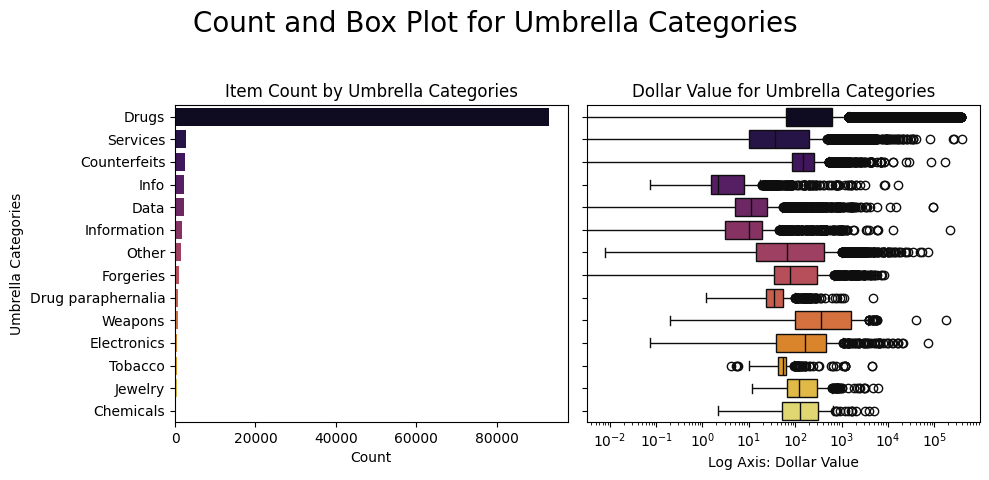

In [ ]:
catplot(target="cat1", level="Umbrella Categories", size = (10,5))
regex1= r'^((?!/).)*$'
print("Groups without Sub-Categories:",df['Category'][df['Category'].str.contains(regex1, na=True)].unique())

In [ ]:
def catinabox_plot(target, parentcat, kitten, level, size = (13,6)):
    f, (ax1, ax2) = plt.subplots(1,2,figsize=size, sharey=True)
    # Count Bar
    bar_count1= df[df[parentcat]==target].groupby([kitten])[['Value']].count().sort_values(by='Value',ascending=False)
    ax1 = sns.barplot(x="Value", y=bar_count1.index, data=bar_count1, ax=ax1,palette="inferno")
    ax1.set_xlabel('Count')
    ax1.set_title('Item Count by {}'.format(target))
    ax1.set_ylabel('{}'.format(target))

    # Box
    ax2 = sns.boxplot(y=kitten, x="Value", order=bar_count1.index, data=df[df[parentcat]==target],palette="inferno")
    ax2.set_xlabel('Log Axis: Dollar Value')
    ax2.set_title('Dollar Value for General Categories')
    ax2.set_xscale('log')
    ax2.set_ylabel('')

    # Plot
    f.suptitle("{} Categories for {}".format(level,target),fontsize=20)
    f.tight_layout(rect=[0, 0.03, 1, 0.95])

Unique Subcategory for Tier Two with SubClass:
 ['Services' 'Drugs' 'Forgeries' 'Tobacco' 'Counterfeits' 'Data'
 'Information' 'Drug paraphernalia' 'Weapons' 'Info']

Tier Two Subcategories
['Hacking' 'Other' 'RCs' 'Physical documents' 'Smoked' 'Money' 'Software'
 'Accounts' 'Clothing' 'eBooks' 'Pipes' 'Weight loss' 'Pirated' 'Steroids'
 'Prescription' 'Guides' 'Scans' 'Accessories' 'Watches' 'Cannabis'
 'Benzos' 'Dissociatives' 'Ecstasy' 'Stimulants' 'Psychedelics'
 'Lethal firearms' 'Opioids' 'Stashes' 'Advertising' 'Melee' 'Containers'
 'Non-lethal firearms' 'Paraphernalia' 'Ammunition' None 'Grinders'
 'Paper' 'Travel' 'Electronics' 'Injecting equipment' 'Barbiturates'
 'Fireworks' 'Scales']


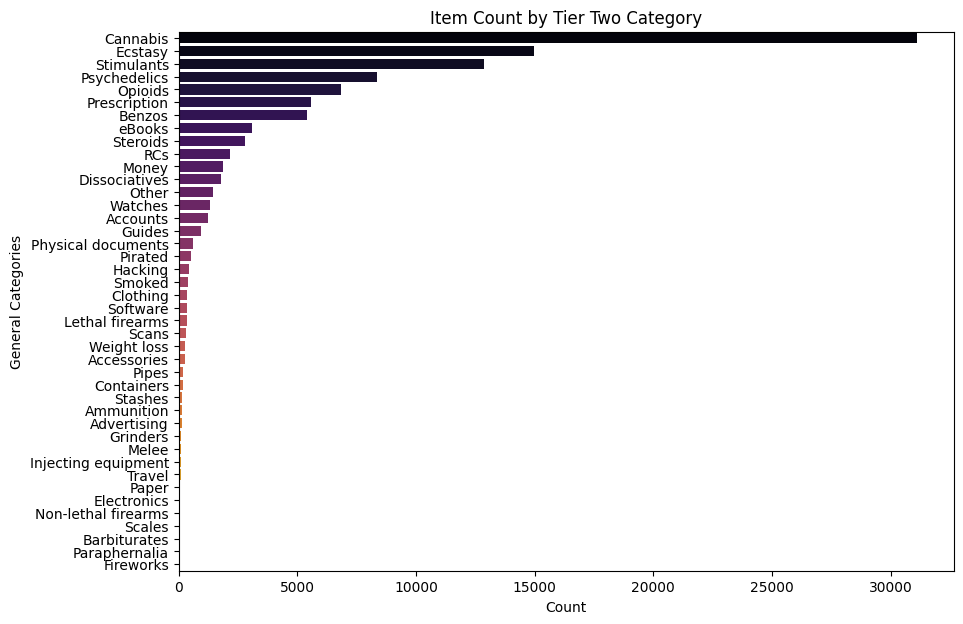

In [ ]:
withsub2 = df.loc[df.cat2.notnull(),["cat1"]].reset_index()["cat1"].unique()
print("Unique Subcategory for Tier Two with SubClass:\n", withsub2)

print("\nTier Two Subcategories")
print(df.query("cat1 in @withsub2")["cat2"].unique())

countplot("cat2", "Tier Two Category", size=(10,7))

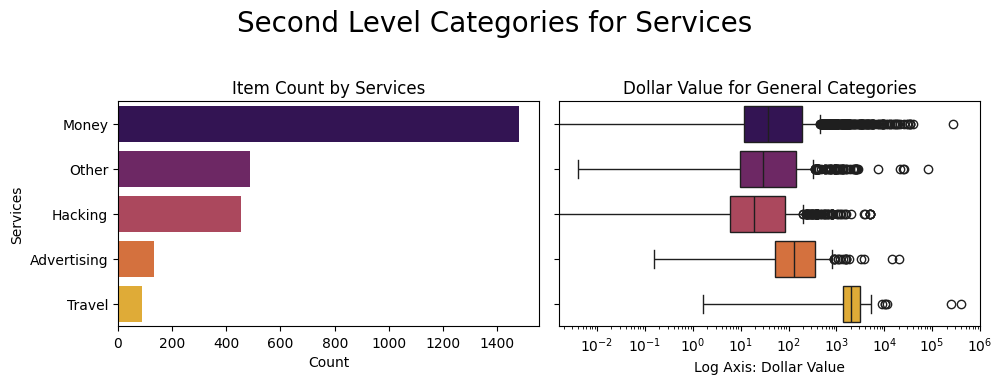

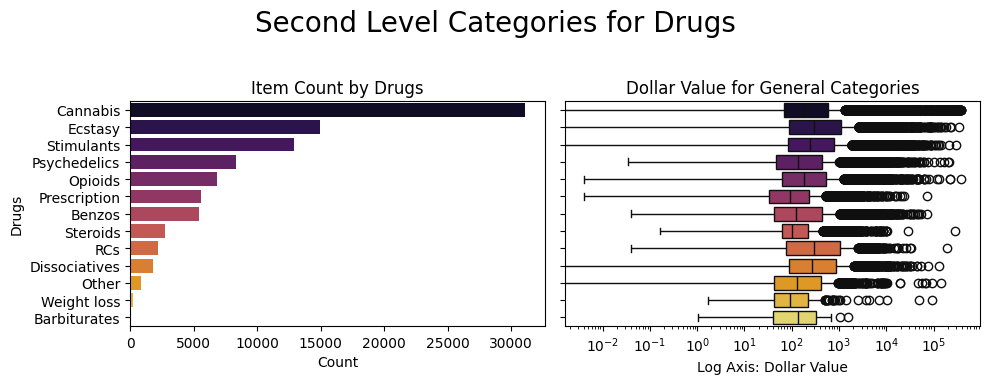

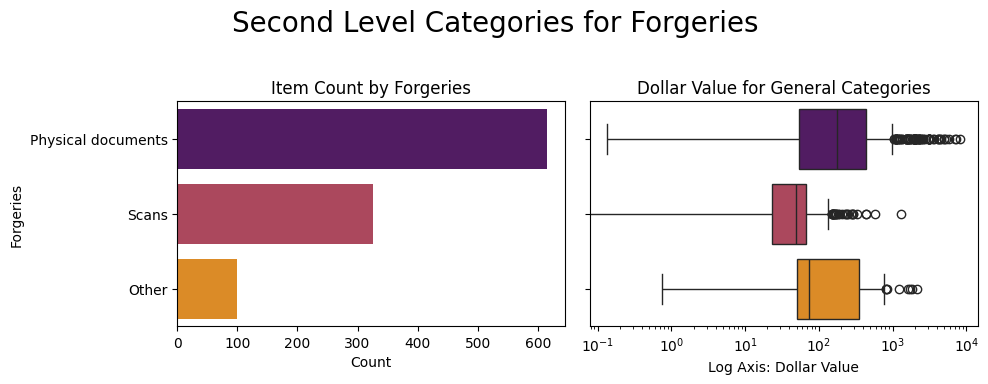

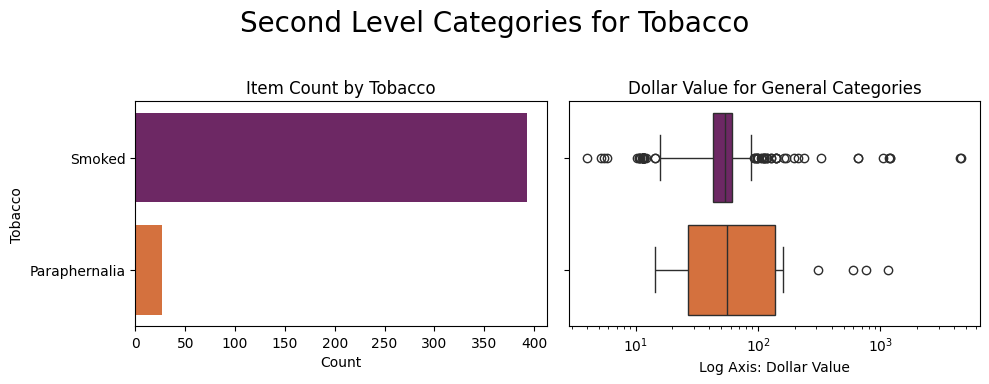

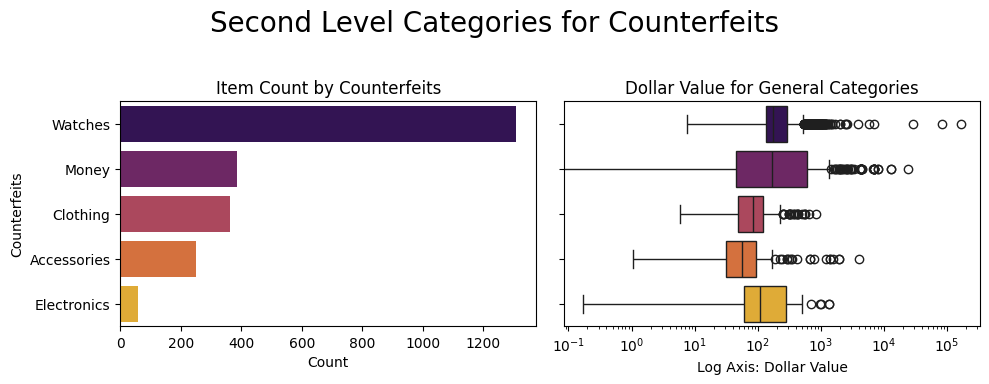

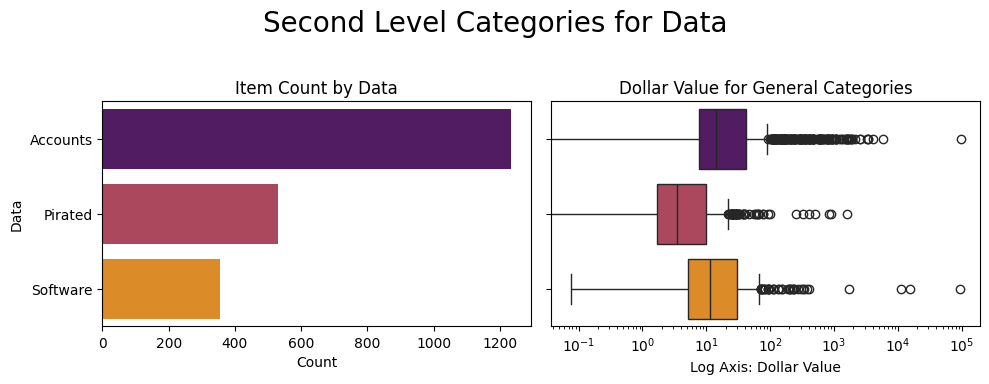

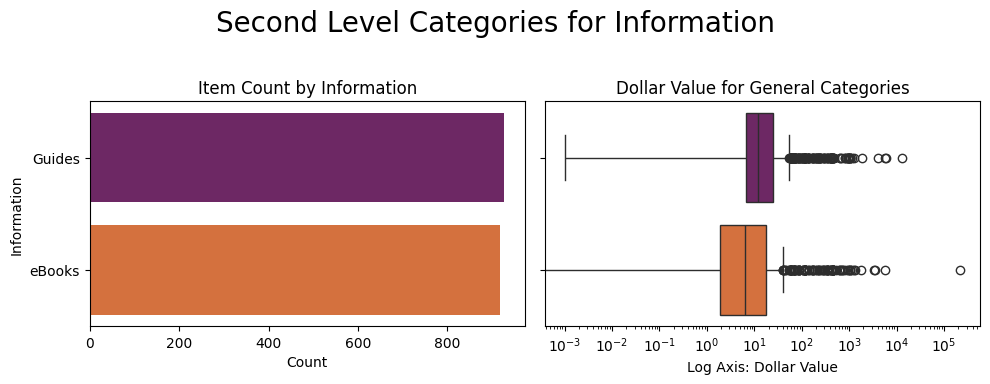

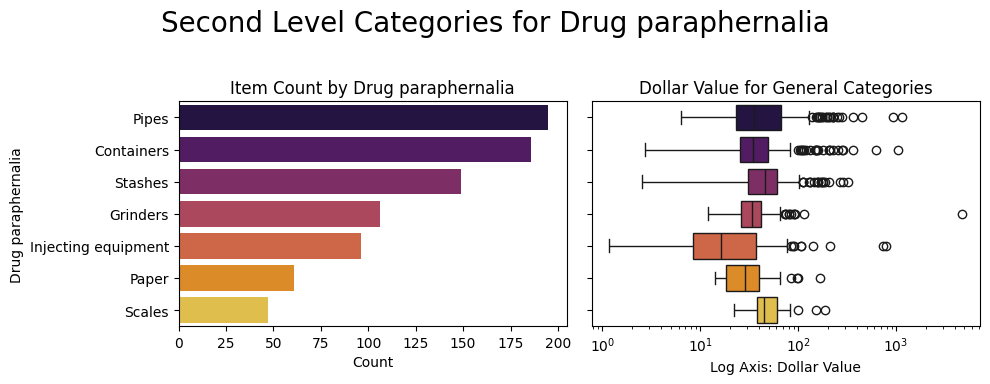

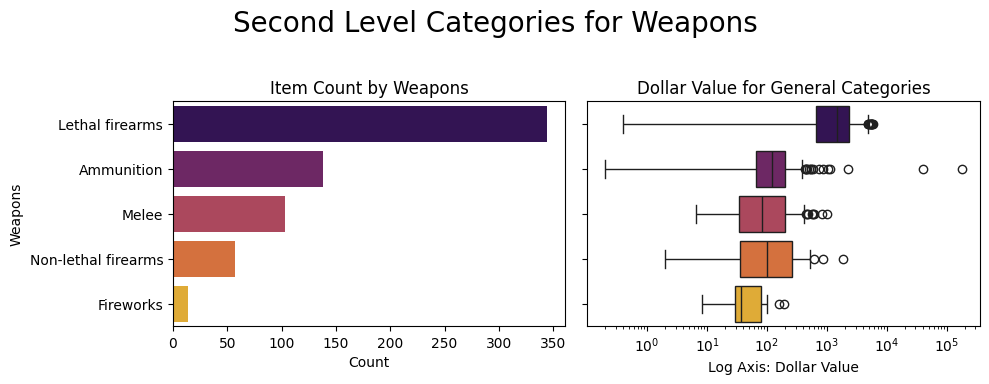

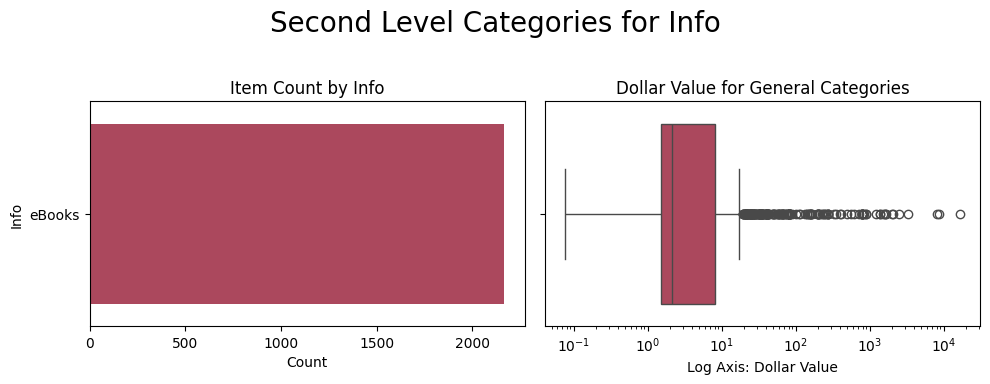

In [ ]:
for x in withsub2:
    catinabox_plot(x, parentcat="cat1",kitten="cat2", level= "Second Level", size = (10,4))

Unique Subcategory for Tier Three with SubClass
 ['Scans' 'Cannabis' 'Dissociatives' 'Ecstasy' 'Stimulants' 'Psychedelics'
 'eBooks' 'Opioids' 'Injecting equipment']

Tier Three Subcategories
[None 'Photos' 'Weed' 'Shake' 'Synthetics' 'Concentrates' 'Seeds' 'Hash'
 'MXE' 'Ketamine' 'Edibles' 'Pills' 'Other' 'Meth' 'LSD' 'Speed' 'GHB'
 'Cocaine' 'NB' 'Mushrooms' 'MDMA' 'DMT' 'Prescription' 'MDA' 'Others'
 'Mescaline' '2C' 'Anonymity' 'Relationships' 'Economy' 'Politics'
 'Morphine' 'Heroin' 'Science' 'Drugs' 'Fentanyl' 'Oxycodone' '5-MeO'
 'Buprenorphine' 'Doomsday' 'IT' 'Psychology' 'Making money' 'Spores'
 'Hydrocodone' 'Philosophy' 'Codeine' 'Aliens' 'Dihydrocodeine'
 'Mephedrone' 'GBL' 'Syringes' 'Opium' 'Salvia' 'Filters' 'Needles' 'PCP']


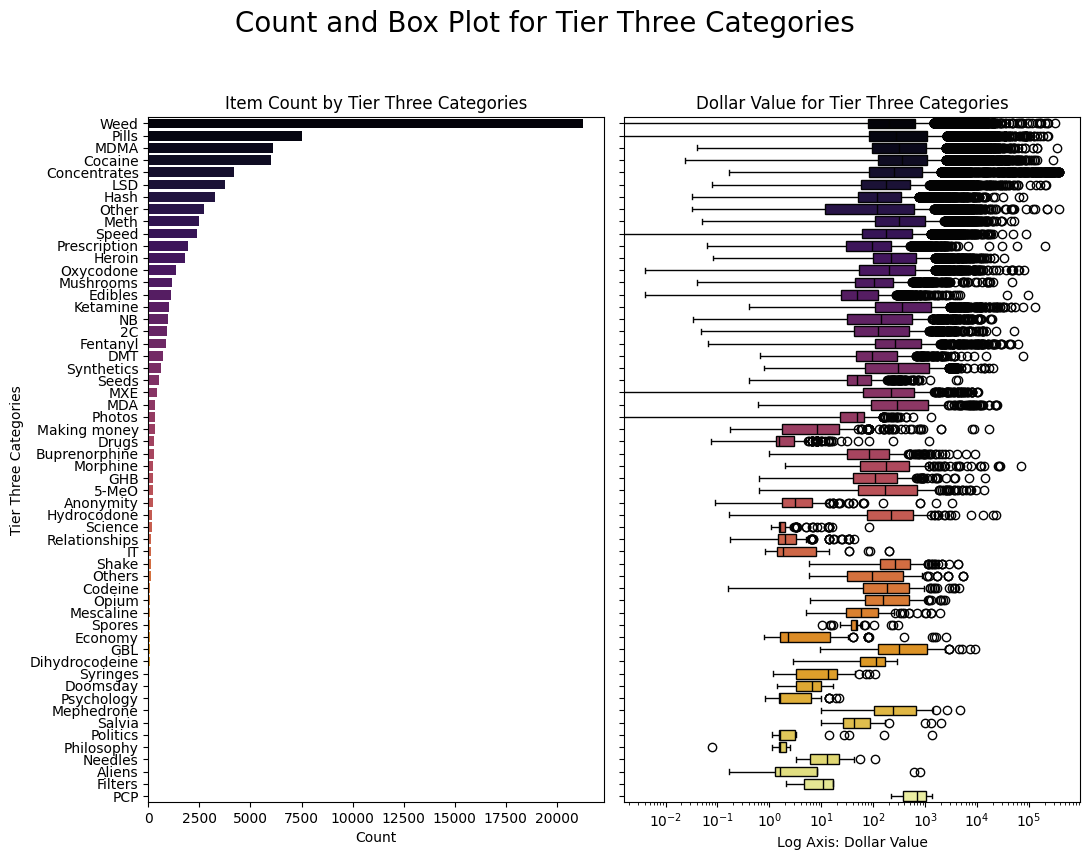

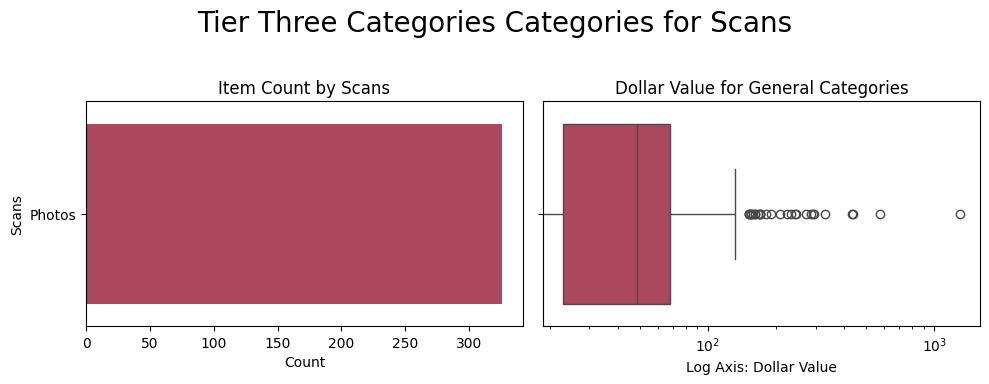

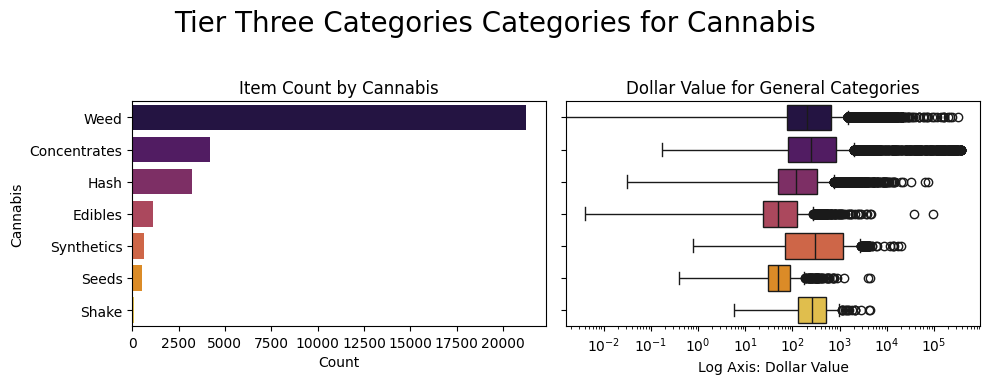

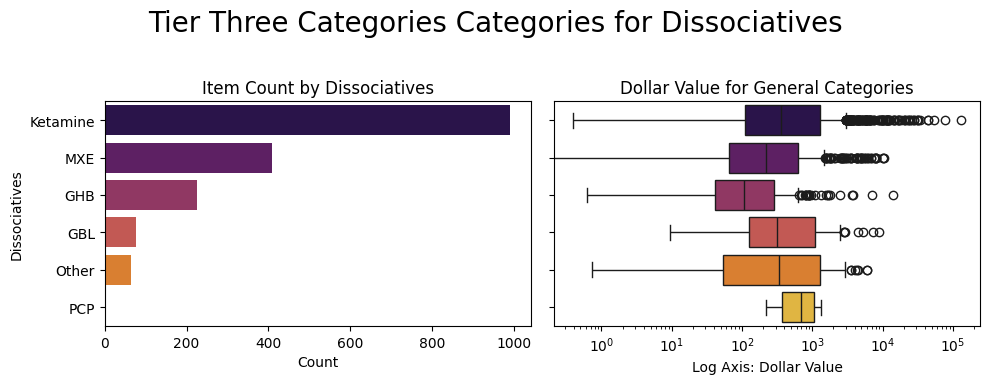

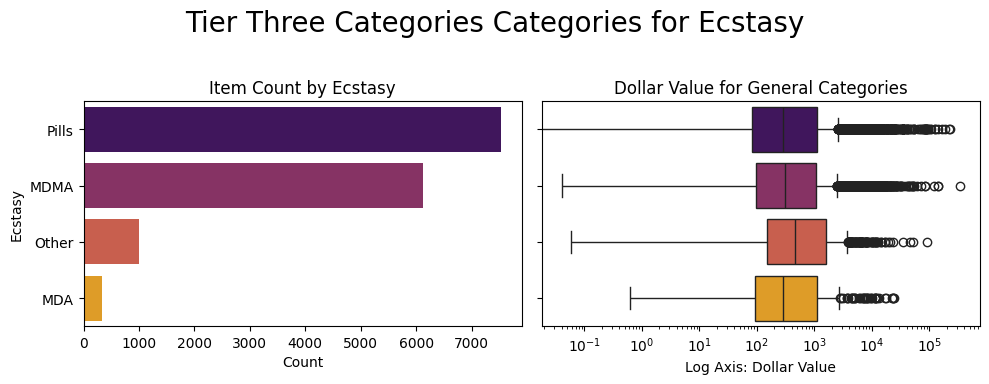

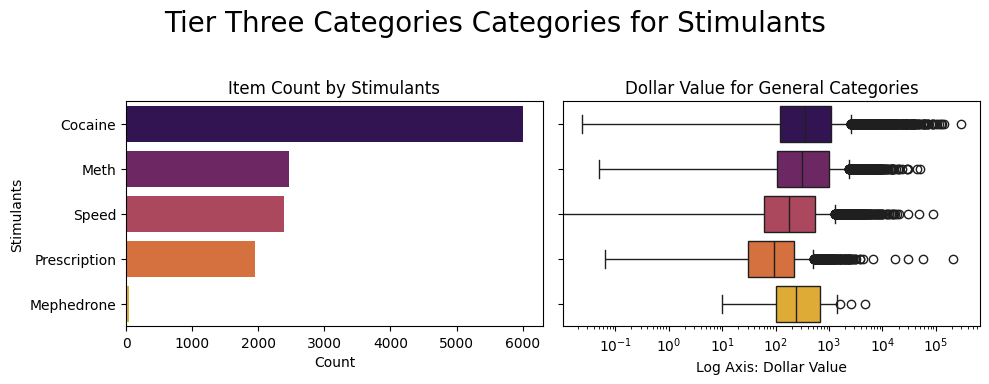

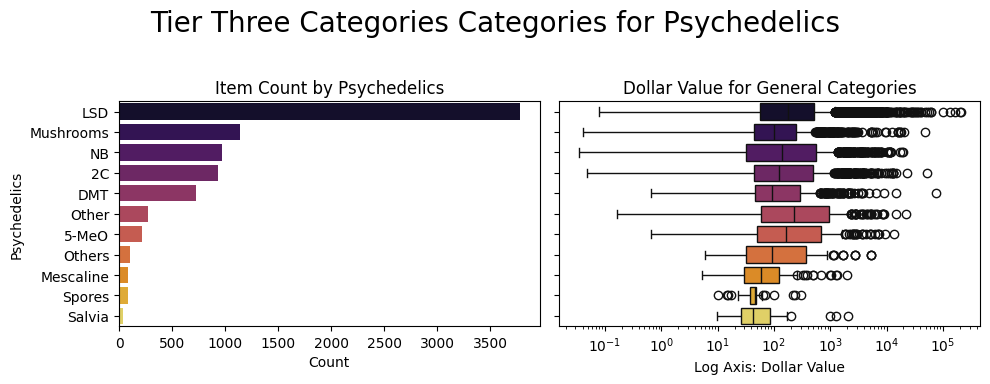

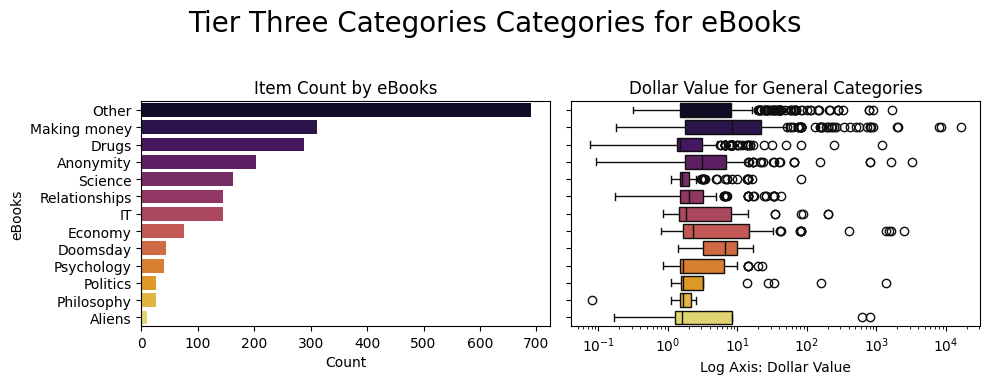

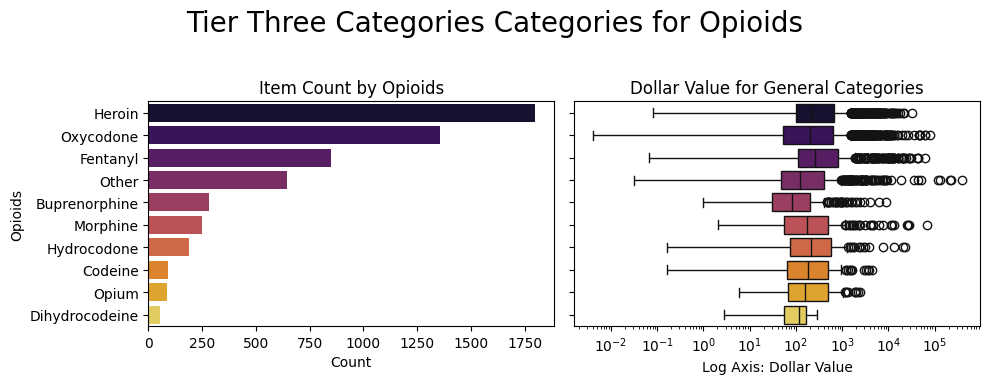

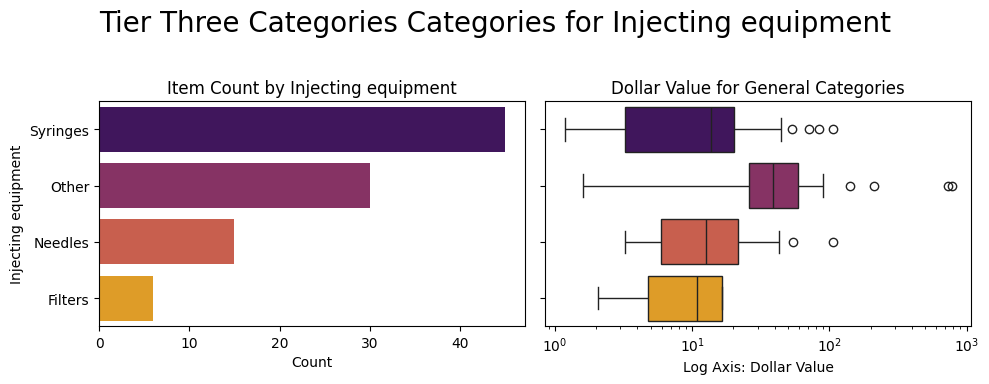

In [ ]:
cats = ["cat1","cat2","cat3", "cat4"]
withsub3 = df.loc[df.cat3.notnull(),["cat2"]].reset_index()["cat2"].unique()
print("Unique Subcategory for Tier Three with SubClass\n",  withsub3)

print("\nTier Three Subcategories")
print(df.query("cat2 in @withsub3")["cat3"].unique())

catplot("cat3", level="Tier Three Categories", size=(11,9))

for x in withsub3:
    catinabox_plot(x, parentcat="cat2",kitten="cat3", level="Tier Three Categories", size=(10,4))

Unique Subcategory for Tier Four with Subclass
 ['Shake' 'Relationships' 'Aliens']

Tier Four Subcategories
['trim' 'Sex' 'UFOs']


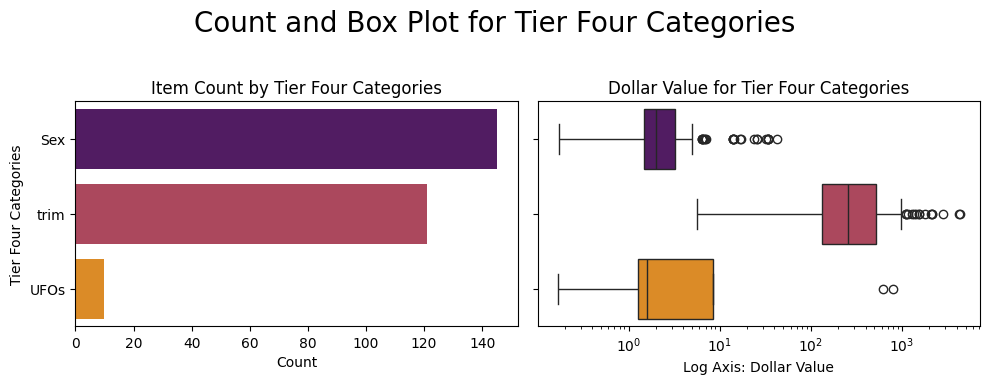

In [ ]:
withsub4 = df.loc[df.cat4.notnull(),["cat3"]].reset_index()["cat3"].unique()
print("Unique Subcategory for Tier Four with Subclass\n", withsub4)
print("\nTier Four Subcategories")
print(df.query("cat3 in @withsub4")["cat4"].unique())

catplot("cat4", level="Tier Four Categories", size=(10,4))

In [ ]:
from nltk import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

size = (10,7)
# Function
def cloud(text, title):
    # Processing Text
    stopwords = set(STOPWORDS)
    wordcloud = WordCloud(width=800, height=400,
                         ).generate(" ".join(text))

    # Output Visualization
    fig = plt.figure(figsize=size, dpi=80, facecolor='k',edgecolor='k')
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=50,color='y')
    plt.tight_layout(pad=0)
    plt.show()

lemm = WordNetLemmatizer()
class LemmaCountVectorizer(CountVectorizer):
    def build_analyzer(self):
        analyzer = super(LemmaCountVectorizer, self).build_analyzer()
        return lambda doc: (lemm.lemmatize(w) for w in analyzer(doc))

# Define helper function to print top words
def print_top_words(model, feature_names, n_top_words):
    for index, topic in enumerate(model.components_):
        message = "Topic #{}: ".format(index)
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1 :-1]])
        print(message)

def LDA(data, name=""):
    # Storing the entire training text in a list
    text = list(data.values)
    # Calling our overwritten Count vectorizer
    tf_vectorizer = LemmaCountVectorizer(max_df=0.95, min_df=2,
                                              stop_words='english',
                                              decode_error='ignore')
    tf = tf_vectorizer.fit_transform(text)


    lda = LatentDirichletAllocation(n_components=8, max_iter=5,
                                    learning_method = 'online',
                                    learning_offset = 50.,
                                    random_state = 0)

    lda.fit(tf)

    n_top_words = 10
    print("\n{} Topics in LDA model: ".format(name))
    # Updated: get_feature_names() changed to get_feature_names_out()
    tf_feature_names = tf_vectorizer.get_feature_names_out()
    print_top_words(lda, tf_feature_names, n_top_words)

# Output
pd.set_option('max_colwidth', 700)
pd.set_option('max_info_columns', 100)

def topic_view(df, catlevel, x):
    df = df[df["ItemDescription"].notnull()]
    print(LDA(df.ItemDescription[df[catlevel]==x], name=x))
    cloud(df['Item'][df[catlevel]==x].values,"Cloud for {}".format(x))

    return df.loc[df[catlevel]==x,["Item","ItemDescription","Value"]].sort_values(
        by='Value',ascending=False).sample(4)

### NLP and Topic Modeling Setup
This section prepares our text analysis pipeline:
1.  **WordCloud**: A function to visualize common terms in item titles.
2.  **LemmaCountVectorizer**: A custom vectorizer that performs lemmatization (reducing words to their root form) during tokenization.
3.  **LDA (Latent Dirichlet Allocation)**: A function that applies unsupervised machine learning to 'ItemDescription' to discover 8 distinct topics within a specific category.

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Weapons Topics in LDA model: 
Topic #0: gun 22 round brand time shipping new order bought 100
Topic #1: und lauf zustand mit sehr mehr deutschland natã¼rlich walther incl
Topic #2: listing shipping round glock ammo magazine escrow 100 order item
Topic #3: blade size cm knife ship handle color material length shipping
Topic #4: wie besprochen mentioned baton laser aluminum blue steel expandable victim
Topic #5: gun new glock loud 9mm come shot piece mag small
Topic #6: custom listing ship fe shipped buyer reship good australia pas
Topic #7: http grenade flash knuckle duster lighter com strong escrow xup
None


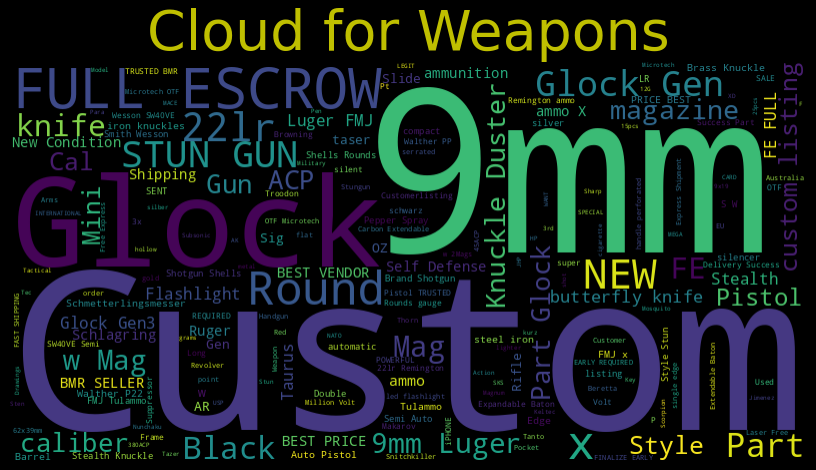

,Item,ItemDescription,Value
93381,JuJuman Custom Part 1,JuJuman Custom Part 1,311.746
91185,Custom for Snitchkiller Part 2,as mentioned please choose free shipping on this,1260.678
33957,submachine gun sa vz.61 Skorpion,Gun in perfect condition. Full auto version. Ammo free - 20pcs Shipping to Germany and Poland : 60Euro Delivery in 3 days . Buyers from another country contact me . link to wikipedia https:// ...,3132.564
33950,AK47c NO FE FULL ESCROW,Comes with 2 30 round 7.62x39mm magazines. ----------------------------------------------------------------------- We do not require FE. We will use full escrow. You will receive yo ...,1216.614


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

topic_view(df=df, catlevel="cat1", x="Weapons")


Lethal firearms Topics in LDA model: 
Topic #0: lauf 9mm cop schalldã 15 al schuss incl kaliber ship
Topic #1: gun new come brand clip 45 shot good price compact
Topic #2: feel walther escrow pp contact good free condition original ger
Topic #3: glock magazine listing round order gun 9mm new escrow 100
Topic #4: escrow listing gun company 50 stealth advanced item offer magazine
Topic #5: ideal action compared role single reduced dimension versatile suppressor threaded
Topic #6: listing shipping custom eu glock used question item discussed new
Topic #7: wie besprochen sehr suppressor semi adapter aber use mit auf
None


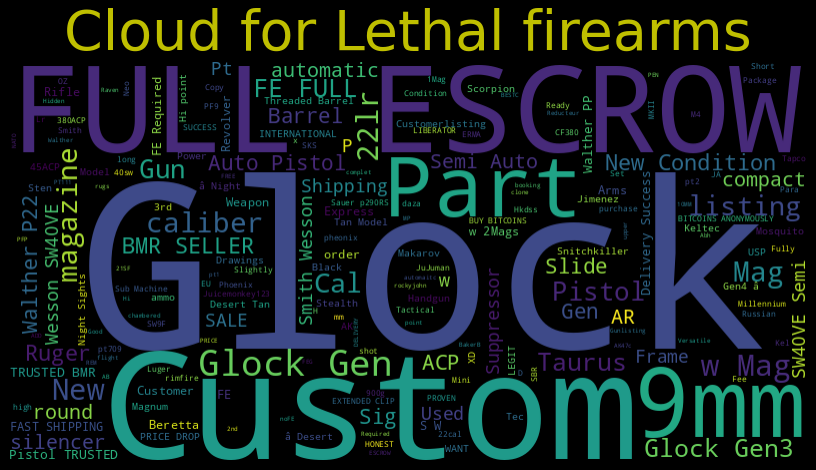

,Item,ItemDescription,Value
17093,Glock 27 part 1/3,Glock 27 three part listing must purchase the shipping option with this listing. The shipping and part 1/3 must be released before shipping,425.957
95443,Tanfoglio Ultra IPSC - 9mm,Tanfoglio Ultra IPSC Approved Kaliber 9mm 5 5 zoll Lauf Stainless-AusfÃ¼hrung. NEUER Lauf! etwas lÃ¤nger als der originale somit SchalldÃ¤mpfermontage mÃ¶glich. Triggerstopp 15-Schuss-Magazin. incl ...,2889.722
87345,NEW MODEL GLOCK 17-EU Only,"NEW MODEL GLOCK 17 WITH FINGER GROOVE GRIP AND RAIL FOR ACCESSORIES. FULL SIZE .9MM WITH 4.5"" BARREL AND FIXED WHITE SIGHTS(ADJUSTABLE SIGHTS AVAILABLE). COMES IN FACTORY HARD CASE WITH TWO 1 ...",1601.339
34660,Silencers,Many models for pistols and rifles contact us for specific inquiries and pricing.,1505.730


In [ ]:
topic_view(df=df, catlevel="cat2", x="Lethal firearms")


Data Topics in LDA model: 
Topic #0: com porn video http website www teen best brazzers girl
Topic #1: method money day music make online page way ebook making
Topic #2: account lifetime listing price working 000 fraction offer 100 send
Topic #3: pricing download link high new site direct ve speed proud
Topic #4: use make listing internet proxy just amazing easy onion highly
Topic #5: need adobe copy server doe custom guide install require special
Topic #6: game license email software key online password address window code
Topic #7: size file format mb duration 00 resolution ªâ byte director
None


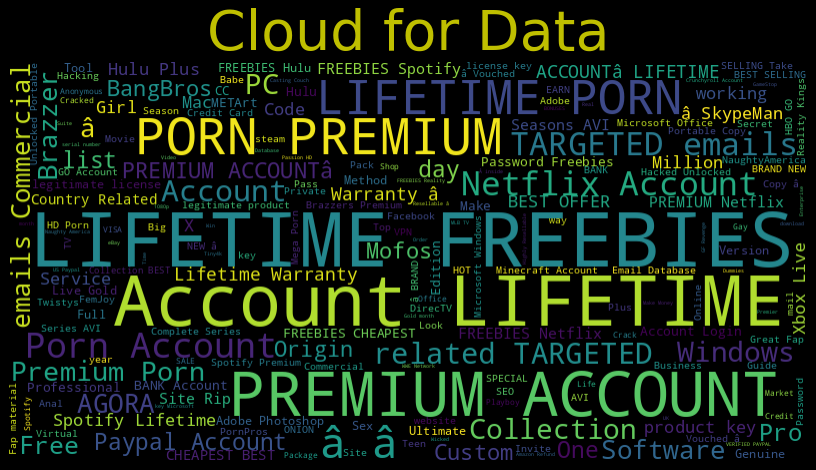

,Item,ItemDescription,Value
1408,Credit Card Checker,This will allow you to see if credit card is valid or not just by simply enter your CC number. It will not show balance of the card! It uses .NET 2.0 Have a look at my other listings you wont b ...,19.037
1500,Netflix [LIFETIME + FREEBIES],Get a Netflix account now for a fraction of the price! When you buy this listing I will send you 2-3 accounts not sent to anyone else. Accounts come with a lifetime warranty so if both accounts ...,3.595
1540,FemJoy Account [LIFETIME + FREEBIES],Get a Femjoy.com account now for a fraction of the price!,12.556
58023,Lynda Premium Account [LIFETIME + FREEBIES],This listing is for a 100% working Lynda Premium account. I will offer a lifetime warranty on these accounts. Lynda.com is an online learning company that helps anyone learn software design and ...,7.418


In [ ]:
topic_view(df=df, catlevel="cat1", x="Data")


Relationships Topics in LDA model: 
Topic #0: day people body best workout beachbody sex really fat instead
Topic #1: sex hot mind secret communication talk new life tool lost
Topic #2: sex men sexual guide sexuality oral woman couple book pleasure
Topic #3: sex oral blow come people away woman going fall guide
Topic #4: people book know easy don learn rest fact understand com
Topic #5: question language minute book thanks 21 work best know 10
Topic #6: female loss content ejaculation size hair page fast format guide
Topic #7: pdf page ebook format size mb file woman dummy content
None


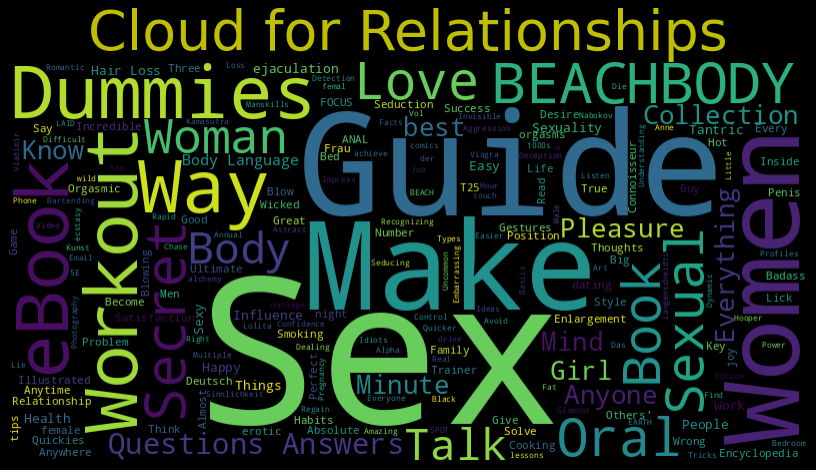

,Item,ItemDescription,Value
62576,Penis enlargement handbook,Hi and thanks for stepping by! This ebook will teach you how to train you penis so it will grow bigger! This e-book will info that not anyone knows. It's not magic everyone can do it. (Eve ...,2.973
62555,Bikini Body Guide HELP Nutrition by Kayla Itsines,Hey you! Thanks for downloading. Please read the full description: FAQ: 1 - How do I open this file? A - This file is a .PDF. When you finish downloading open it with Adobe Reader it should ...,1.514
97047,Don't Put That in There!,"Don't Put That in There! - A Carroll R Vremman People have more access to medical information than ever before with an abundance of printed and online resources and yet we still believe ""facts"" ab ...",1.488
97028,How To Start A Conversation And Make Friends,Small-talk expert Don Gabor has completely revised and updated this definitive guide showing how to combine essential techniques in the art of conversation with necessary skills for communicating in ...,1.508


In [ ]:
topic_view(df=df, catlevel="cat3", x="Relationships")


Drugs Topics in LDA model: 
Topic #0: strain kush bud indica weed sativa grown og indoor cannabis
Topic #1: fe order shipping free listing escrow required ship day early
Topic #2: used drug adderall xanax oxycodone fentanyl alprazolam small mg tablet
Topic #3: pill listing 10 mdma 100 usa uk mg shipping sale
Topic #4: quality product high best mdma price listing new gram pure
Topic #5: hash speed oil stock sell paste red currently business amazing
Topic #6: profile read ordering page 99 order term http purity receive
Topic #7: lsd blotter tab meth mushroom nbome known dmt http contain
None


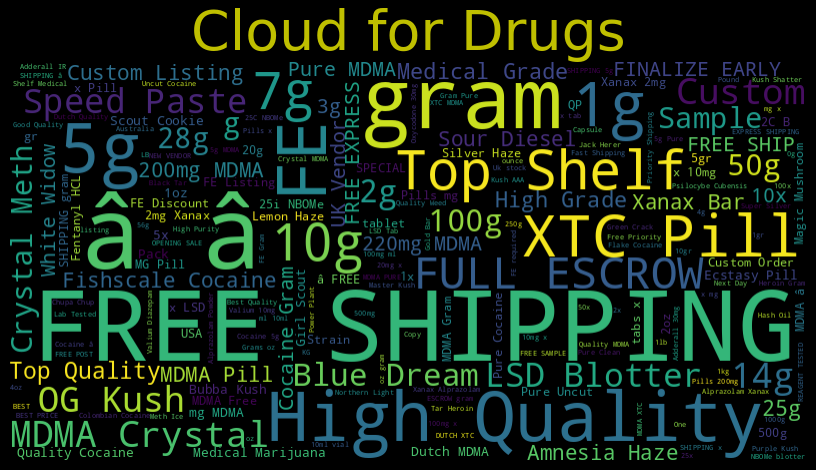

,Item,ItemDescription,Value
45207,Adderall (amphetamine/dextroamphetamine) 30 MG { 60 Pills },Adderall (amphetamine/dextroamphetamine) 30 MG { 60 Pills } Adderall contains a combination of amphetamine and dextroamphetamine. Amphetamine and dextroamphetamine are central nervous system stimu ...,620.906
105193,XTC 200-220mg+ Pills Orange Dom Perignons (x2),The Finest quality pills available; direct from Holland the king of drugs!!!,47.500
65696,100x Orange Lego Pills ~220mg MDMA **DOMESTIC USA**,220mg MDMA Orange Lego Pills Quantity: 100,1655.707
82486,3 grams of gunpowder for $180,3 grams of gun powder. Thats mexican heroin that can be snorted smoked or shot. Its very strong and is alot more potent then this china white for sale. Im offering free shipping on the first 10 b ...,294.767


In [ ]:
topic_view(df=df, catlevel="cat1", x="Drugs")


Opioids Topics in LDA model: 
Topic #0: heroin gram pure listing white product uncut suboxone china 8mg
Topic #1: opiate used pain codeine fentanyl opioid big known test analgesic
Topic #2: ªâ ²â market pgp order evo vendor subutex cook ¼â
Topic #3: pill oxycodone listing tablet oxycontin mg 10 30mg pharmacy release
Topic #4: heroin quality best batch new good bag product brown stuff
Topic #5: profile read heroin black tar listing item ordering gram http
Topic #6: fentanyl time price listing 50 sale 100 30mg order 10
Topic #7: order fe shipping hcl fentanyl pure free listing day 99
None


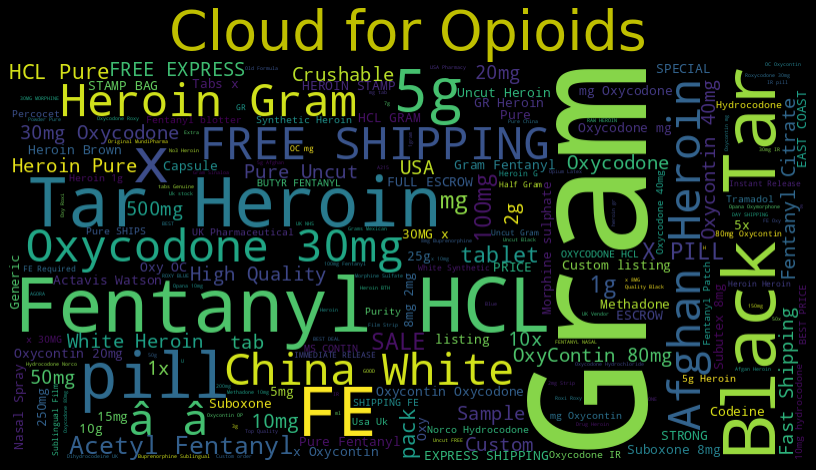

,Item,ItemDescription,Value
103666,Roxycodone 30mg IR (A215),listing is for 1 roxycodone 30mg ir pill. pill is blue with A215 markings. swallow sniff smoke or iv.,29.532
52918,5x [five] 30mg Oxycodone Oxy Mallinckrodt M 30 White Fast Free Shipping,5x [five] 30mg Oxycodone Oxy Mallinckrodt M 30 White round pills Pills always come from USA pharmacies. No expired junk. No fakes. Rare to get a cracked pill they will never be crushed. ** Exp ...,190.579
54646,20X NORCO (10mg Hydrocodone 325 mg acetaminophen) $7.50each!,20x NORCO (10mg Hydrocodone 325 mg acetaminophen) Thats $7.50 a piece! (Lowest price on the darkwebs!) CURRENT INVENTORY ARE WHITE WITH IP 110 ON THEM Hello AGORA patrons! We are MedRight b ...,165.521
85050,Oxycodon-HCI 80 mg betapharm,German quality from beta pharm 80mg Oxycodon ret ATTENTION THESE ARE THE STROGEST YOU CAN GET!!! Only buy this if u know what u r doing these are very very very strong! same as Mundiph ...,29.754


In [ ]:
topic_view(df=df, catlevel="cat2", x="Opioids")


Cannabis Topics in LDA model: 
Topic #0: strain bud gram blue hybrid dream indoor shelf grade type
Topic #1: shipping free order day quality gram ship listing fe product
Topic #2: sativa haze strain indica high diesel sour strong hybrid taste
Topic #3: weed cannabis organic seed grown quality high best 100 white
Topic #4: price strain order quality listing available best fe weed good
Topic #5: kush og purple strain indica hash nice bud bubba nugs
Topic #6: profile read hash ordering page ºâ quality listing order fe
Topic #7: shatter wax bho oil purged butane listing bag high little
None


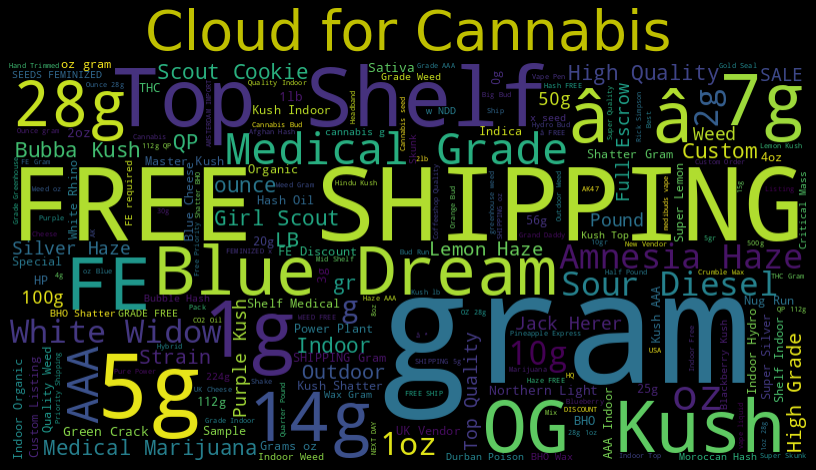

,Item,ItemDescription,Value
41768,84g of Dutch Amnesia Haze - FE - UK Only!,UK customers ONLY! Imported Dutch Amnesia Haze. Not quite coffee shop quality IMO but close and definitely in the high end of the UK market. PRICES \tFE 14g\tÂ£133/$206 (Â£9.5/g) 20g\tÂ£18 ...,1778.854
37520,10g CO2 Rick Simpson Oil (RSO 90% THC) FREE SHIPPING,** Contact Email in Case of Site Outage: jemdikRR@mail1click.com ** TOP OREGON CHRONIC provides the best medical-grade chemist-extracted marijuana concentrates that you can get. Oregon has a w ...,487.691
40390,20g of Ballerblume 6,(You can stack up to 2*20g for one postage) We give allways overweight more you order more overweight. This strain is cross of: Ballerblume 6 Â»Â»Â» {Buschmans x Afghan} x {Skunk x Afghan} Br ...,122.596
95174,20g Weed Power Plant homegrown 1 Gram,/////////////////////////////////////////////////////////////////////////// 20 grams of Power Plant weed. Homegrown organic a bit resinous and tasty. ///////////////////////////////////////// ...,188.420


In [ ]:
topic_view(df=df, catlevel="cat2", x="Cannabis")


Prescription Topics in LDA model: 
Topic #0: modafinil pill mg 200mg generic pharmacy capsule modalert good great
Topic #1: box medication used gabapentin lorazepam prescribed drug opioid prescription sell
Topic #2: ambien powder cost pure milligram www time com som zolpidem
Topic #3: tablet adderall pill listing blister product 20mg release pack 30
Topic #4: viagra tramadol cialis 100 100mg tab generic mg sildenafil pill
Topic #5: xanax shipping 10mg order pill listing price soma bar 10
Topic #6: used fast treat high shipping quality message disorder online anxiety
Topic #7: ritalin clonazepam offer methylphenidate attention 50 wirkstoff receive rivotril ingredient
None


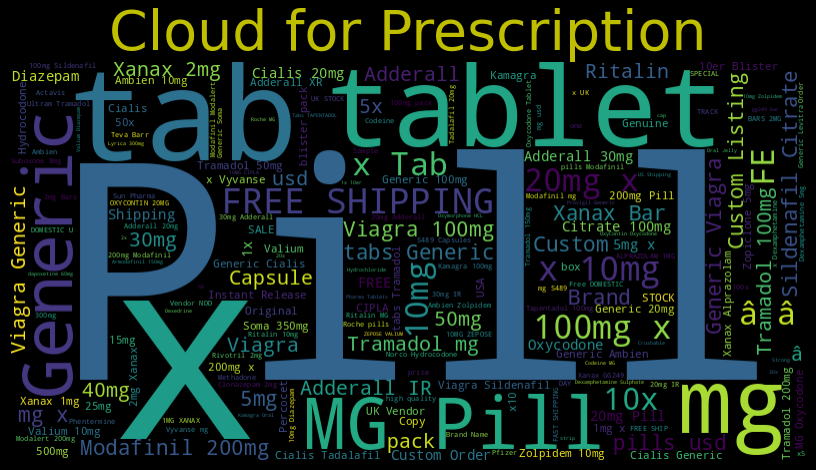

,Item,ItemDescription,Value
44842,200 Phentermine k25 37.5 mg $295,200 Phentermine k25 37.5 mg $295,496.910
3386,200 tabs x Generic Levitra Vardenafil pills 20MG,200 tabs x Generic Levitra Vardenafil pills 20MG,59.122
29031,5 Pack Of 5mg Methadone Pill-Mallinckrodt Mfr.,*NOTE* Please read profile page prior to making order... I'm currently offering: 5 Pack of 5MG METHADONE (Methadone hydrochloride) manufactured by Mallinckrodt Pharmaceuticals. *Methadone hy ...,34.108
30745,1 X SUBOXONE FLIM 2/.5mg Very Fresh Stock Always Fast Shipping SPECIAL AS WE ARE NEW!!!,Welcome SPECIAL PRICE AS WE ARE NE AND WANT TO SHOW WHAT WE CAN DO! This Listing Is For 1 X SUBOXONE 2/0.5mg Film. SPECIAL $9us each Shipping Aus Express Post Only Late Cut Off Time To Help ...,11.921


In [ ]:
topic_view(df=df, catlevel="cat2", x="Prescription")


Prescription Topics in LDA model: 
Topic #0: vyvanse listing 60mg fe adderall 70mg ve effect similar last
Topic #1: generic modafinil drug cials 200mg uk brand pharma modalert class
Topic #2: viagrageneric viagra hydrocodone sildenafil dysfunction used chemical feedback sexual military
Topic #3: ritalin methylphenidate tablet blister used mg brand attention concerta hyperactivity
Topic #4: message valium com benzodiazepine pgp begin http drug www 10mg
Topic #5: shipping 100mg viagra product dexamphetamine 5mg free pill tablet day
Topic #6: adderall listing pill cialis order 20mg ir 30mg mg tablet
Topic #7: vendor price new adderall rating order looking offering mission 10
None


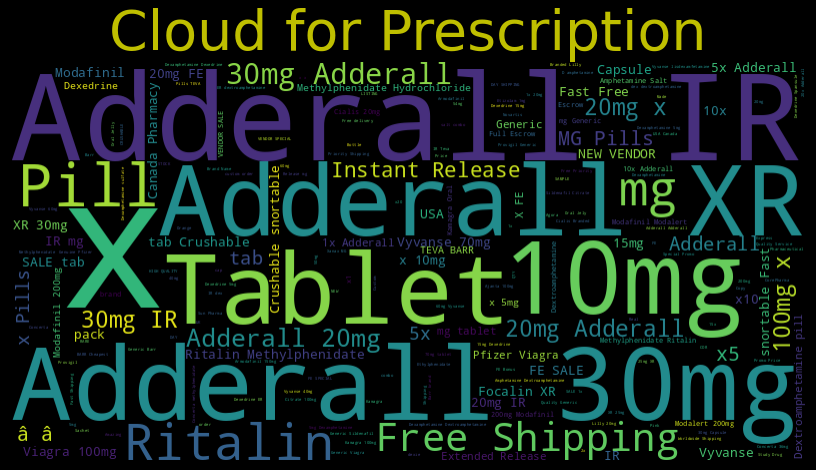

,Item,ItemDescription,Value
27515,50x37.5mg Phentermine K-25 BEST price! (WORLDWIDE SHIPPING),*PRO TIP* If you need more just add the same item multiple times to your cart the shipping fee stays the same :) *Newbie TIP* Early finalization is never required with us but appreciated and wil ...,113.397
27465,âââ Adderall 20mg,See profile listing :) Adderall Adderall Adderall,64.819
70518,Oxycontin (Oxycodone Hydrochloride) 4 x 80mg,Generic OxyContin (OxyCodone Hydrochloride) 80mg tablet Check my other listings for larger quantities. If you don't see the quantity you are looking for please send me a private message Free ...,155.634
17273,100 Ritalin x 10 mg x 230$,Ritalin 10 mg x 100 pills Novartis,222.336


In [ ]:
topic_view(df=df, catlevel="cat3", x="Prescription")

In [ ]:
df.cat2[df.cat1 == "Drugs"].unique()

array(['RCs', 'Weight loss', 'Steroids', 'Prescription', 'Other',
       'Cannabis', 'Benzos', 'Dissociatives', 'Ecstasy', 'Stimulants',
       'Psychedelics', 'Opioids', 'Barbiturates'], dtype=object)


UFOs Topics in LDA model: 
Topic #0: good ebook edition
Topic #1: good edition ebook
Topic #2: ebook good edition
Topic #3: edition ebook good
Topic #4: good edition ebook
Topic #5: edition good ebook
Topic #6: good ebook edition
Topic #7: ebook edition good
None


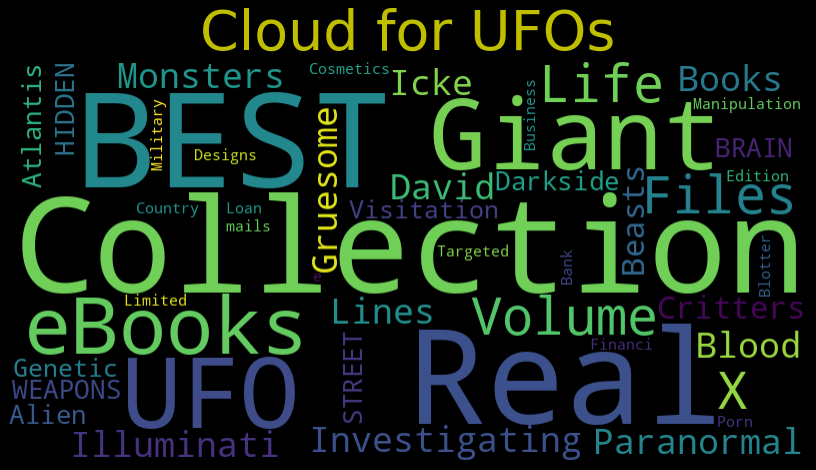

,Item,ItemDescription,Value
62678,Real Monsters Gruesome Critters and Beasts from the Darkside,Spotlighting news articles historical accounts and firstperson interviews this chronicle of human interactions with monsters will convince even the most hardened skeptic of the existence of the bo ...,0.167
62679,THE 100% BRAIN,igital ebook. Many people think that the concept of using 100% of their brain is impossible for them to achieve. They think it is more normal to use 2% 5% 10% or 20% of their brain and they may e ...,1.175
62676,David Icke Collection (75 Books),"David Icke (pronounced ""Ike"") is a former Professional Soccer player journalist network anchorman with the BBC spokesman in the 1980's for the British Green Party and since 1990 a full time inves ...",8.374
62674,Giant Collection of UFO eBooks Volume 2,This is my giant collection of UFO books on PDF. I uploaded this because I looked all over and there wasn't any good collections of UFO books on any bittorrent sites. All of these except for a couple ...,1.649


In [ ]:
topic_view(df=df, catlevel="cat4", x="UFOs")

### Category-Specific Topic Analysis
The preceding cells execute the `topic_view` function across various categories (Weapons, Drugs, Opioids, UFOs, etc.). For each category, it prints discovered text topics, generates a WordCloud of item names, and displays a sample of high-value listings.